In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import ( OrdinalEncoder, OneHotEncoder, StandardScaler)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

In [ ]:
print(train.shape)
print(test.shape)
print(train.columns)
print(test.columns)

(690088, 15)
(295753, 14)
Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')
Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')


In [ ]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [ ]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [ ]:
train.describe()
#No problem with any too extreme values outliers can exist but no impossible values
#mean and median is almost equal so no issues in extremem outliers that affect the values too much
#there are some null values for sure have to see the data before filling
#the coeffienct of varience is high is most of the columns meaning the data is more spread out
#a bit more variation in calorie expenditure more than others,
#standard deviation for step_count is quite large

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [ ]:
train.shape

(690088, 15)

In [ ]:
#seperating columns now for better viewing
num_cols = train.select_dtypes(include = "number").columns
cat_cols = train.select_dtypes(exclude= "number").columns

Skewness for step_count is -0.18023843603832704
Skewness for BMI is 0.024639760001979885
Skewness for calorie_expenditure is -0.1839399892368627
Skewness for water_intake is 0.10996029570066149


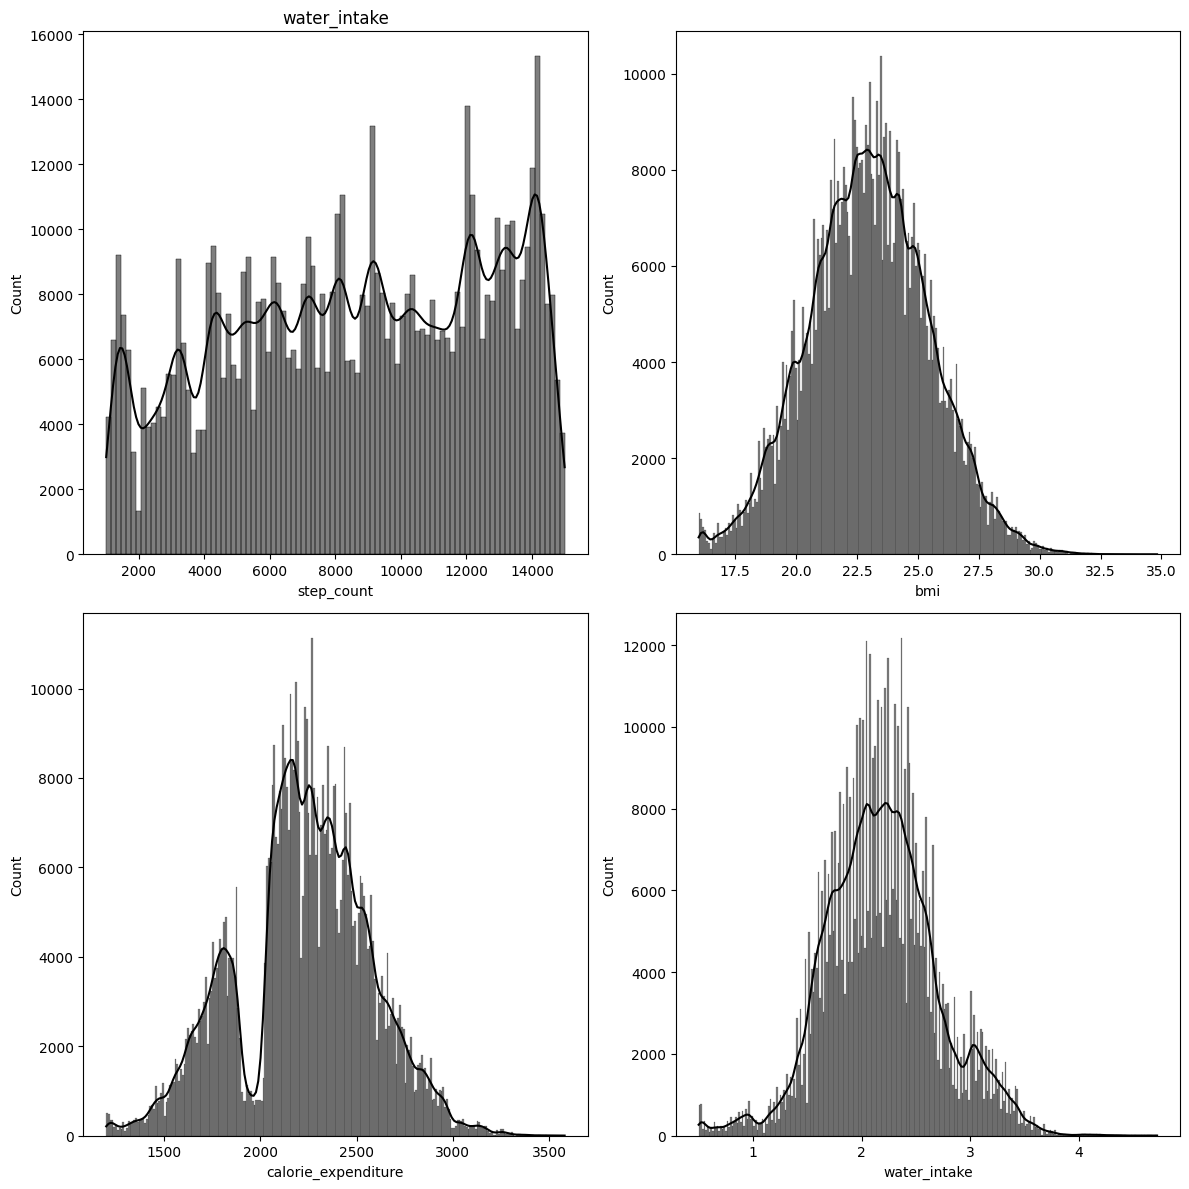

In [ ]:
#histogram plot to check cols with the most variation
fig,axes = plt.subplots(2,2,figsize = (12,12))
sns.histplot(train["step_count"], ax = axes[0,0], color = "Black", kde = True)
axes[0,0].set_title("Stepcount")
print(f"Skewness for step_count is {train["step_count"].skew()}")
sns.histplot(train["bmi"], ax = axes[0,1], color = "Black", kde = True)
axes[0,0].set_title("BMI")
print(f"Skewness for BMI is {train["bmi"].skew()}")
sns.histplot(train["calorie_expenditure"], ax = axes[1,0], color = "Black", kde = True)
axes[0,0].set_title("calorie_expenditure")
print(f"Skewness for calorie_expenditure is {train["calorie_expenditure"].skew()}")
sns.histplot(train["water_intake"], ax = axes[1,1], color = "Black", kde = True)
axes[0,0].set_title("water_intake")
print(f"Skewness for water_intake is {train["water_intake"].skew()}")
plt.tight_layout()
plt.show()

In [ ]:
#1. step_count = we can see that there is a large variety of data cause the data range is so wide, distribution of the data isn't normal as well, it is multimodel which means there are more than one peaks
    # reason of that could be people like to have a goal through the data and we are taking the measured data as well as there is no obvious skewness as well means no right or left skewed
    #the number of outliers isn't fully exactly shown in histogram so have to see boxplot to confirm this,
    #action steps from this: see boxplot for outliers, see relationship with the target variable
#2. BMI and water intake normal stuffs
#3. Calorie expendicture = we can see that it is a multimodel type graph so have to think about the reason for it, it can be due to make men burn more calorie than women, or men exercise more than women,
    #cofirm with boxplot for outliers and see the relationship with the target variable and gender, and exercise

Text(0.5, 1.0, 'Gender vs exercise_duration')

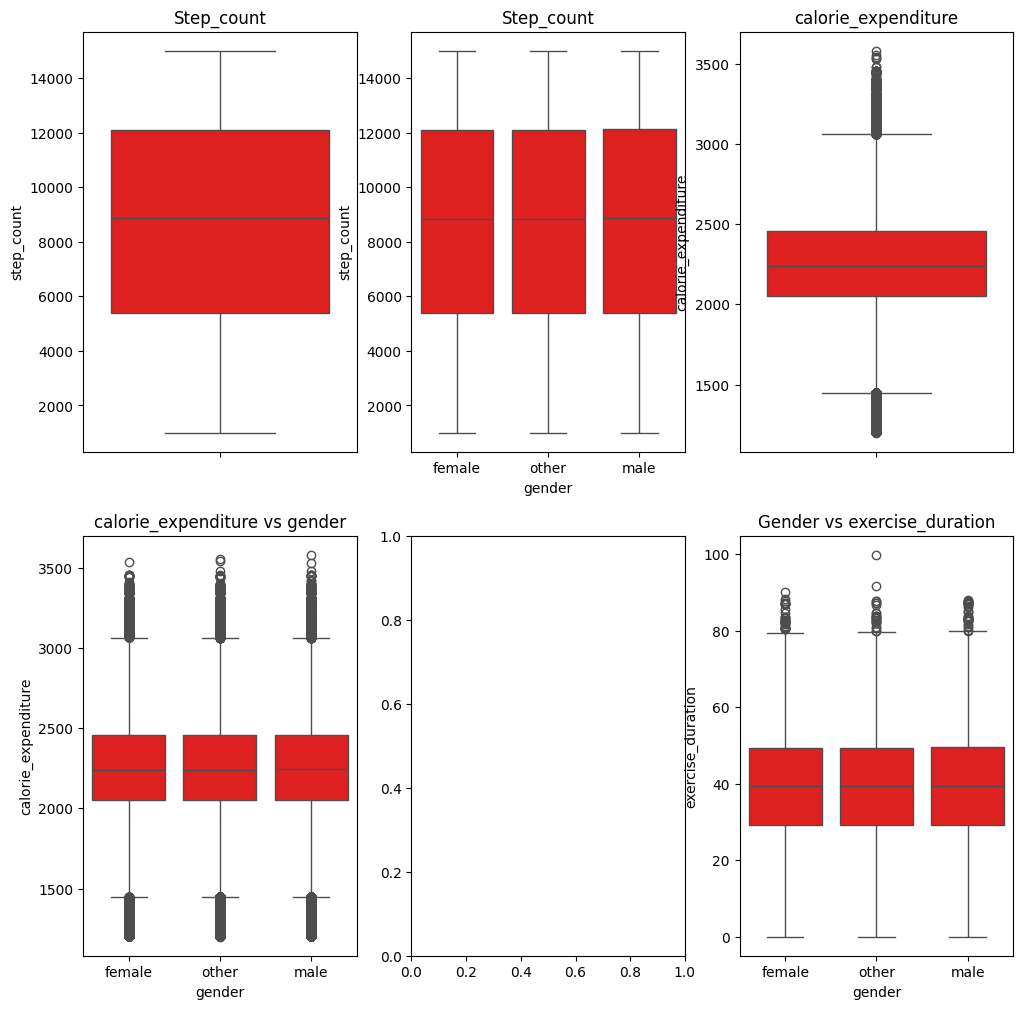

In [ ]:
#Taking all the action steps from above by plotting boxplot
fig, axes = plt.subplots(2,3, figsize=(12,12))
sns.boxplot(train["step_count"], ax = axes[0,0], color = "Red")
axes[0,0].set_title("Step_count")
sns.boxplot(x = train["gender"],y = train["step_count"], ax = axes[0,1], color = "Red")
axes[0,1].set_title("Step_count")
sns.boxplot(train["calorie_expenditure"], ax = axes[0,2], color = "Red")
axes[0,2].set_title("calorie_expenditure")
sns.boxplot(x = train["gender"],y = train["calorie_expenditure"], ax = axes[1,0], color = "Red")
axes[1,0].set_title("calorie_expenditure vs gender")
sns.boxplot(x = train["gender"],y = train["exercise_duration"], ax = axes[1,2], color = "Red")
axes[1,2].set_title("Gender vs exercise_duration")

In [ ]:
#step count has no ouliers and showes wide variety of data, no gender does more steps than others and
# caloie expenditure shows outliers there are many who spend less than 1500 calorie everyday and many do burn moe than 3100 about
# all genders have outliers for both cases no spending calorie no relation in that#
# Exercise duration is similar across genders, although a few individuals exercise substantially longer than the majority.

# ACtion steps; see more about calorie expenditure and exercise duration and see if they are possible things in the data or not

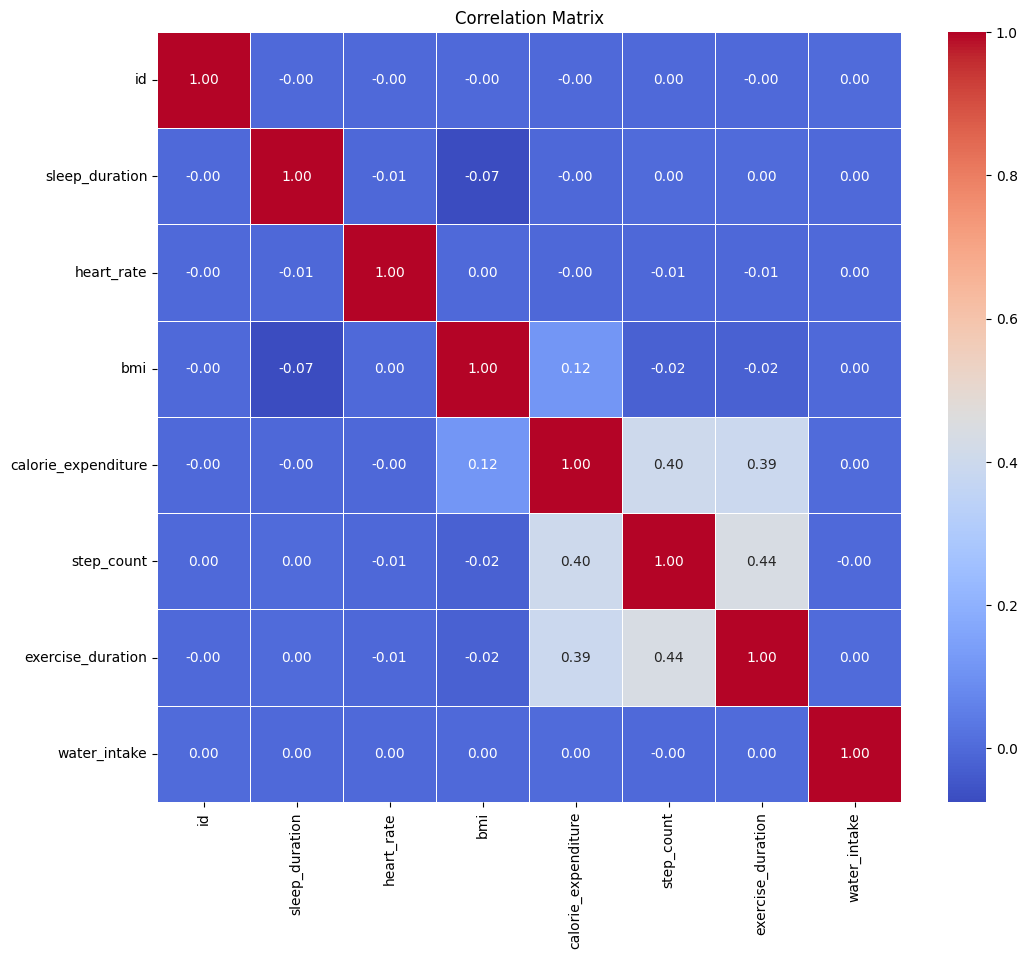

In [ ]:
#coorelation matrix
corr = train[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#as per this we can see that calorie expenditure is related to exercise duration which is obvious and so is step count
#exercise diruation, step count and calorie expenditure are all interelated with each other in short
#sleep duration heart rate bmi and water intake all don't have much corelation with each other, they can be coorelated to the finsh of course
#action step- now let's make a scatterplot for strongly related features

['unhealthy' 'at-risk' 'fit']


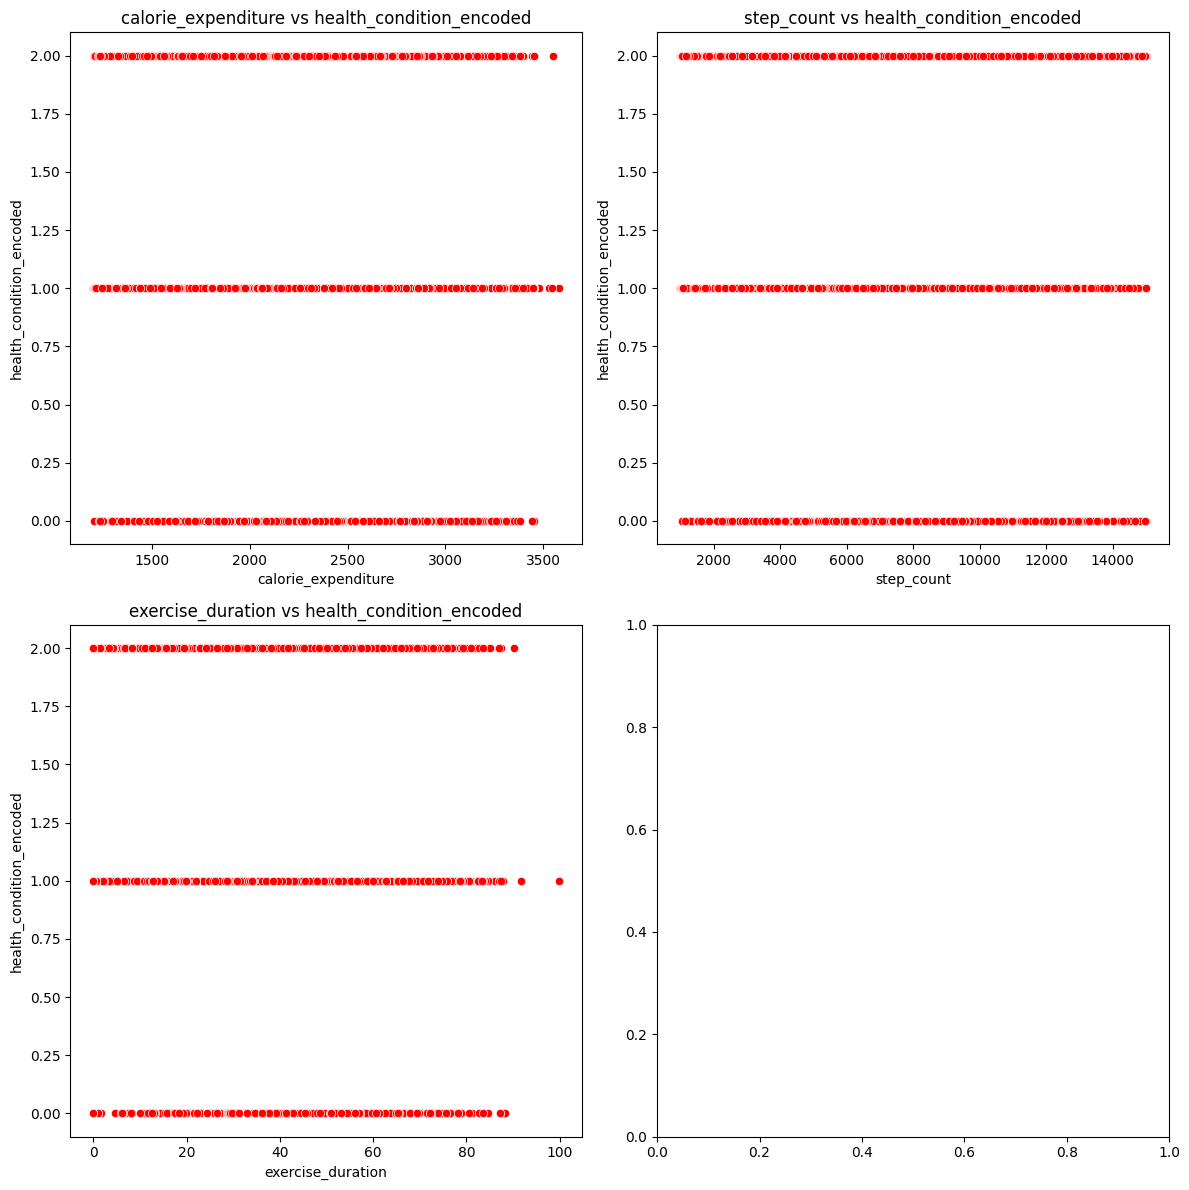

In [ ]:
train["health_condition"].unique()
mapping = {
    "fit": 0,
    "at-risk": 1,
    "unhealthy": 2
}
train["health_condition_encoded"]= train["health_condition"].map(mapping)
print(train["health_condition"].unique())
fig, axes = plt.subplots(2,2, figsize = (12,12))
sns.scatterplot(data = train, x = "calorie_expenditure", y = "health_condition_encoded", ax = axes[0,0], color = "Red")
axes[0,0].set_title("calorie_expenditure vs health_condition_encoded")
sns.scatterplot(data = train, x = "step_count", y = "health_condition_encoded", ax = axes[0,1], color = "Red")
axes[0,1].set_title("step_count vs health_condition_encoded")
sns.scatterplot(data = train, x = "exercise_duration", y = "health_condition_encoded", ax = axes[1,0], color = "Red")
axes[1,0].set_title("exercise_duration vs health_condition_encoded")
plt.tight_layout()
plt.show()

#sooo it was a mistake cause thse values are discrete I should have used boxplot

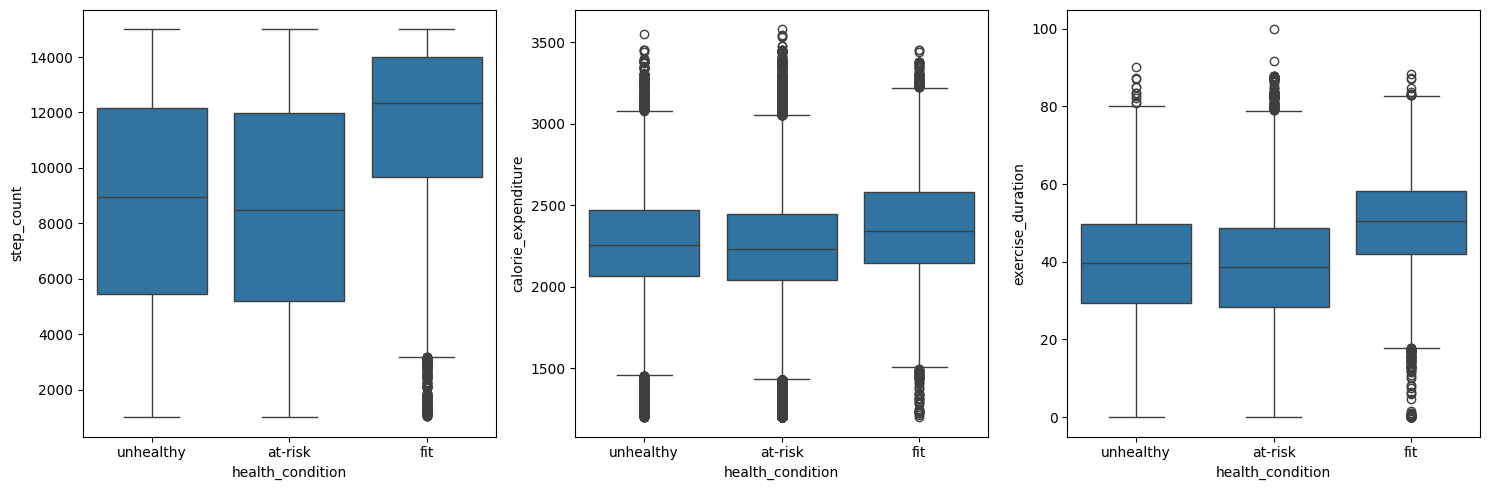

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=train, x="health_condition", y="step_count", ax=axes[0])
sns.boxplot(data=train, x="health_condition", y="calorie_expenditure", ax=axes[1])
sns.boxplot(data=train, x="health_condition", y="exercise_duration", ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# firset the first plot we can conclude that fit people takes more step than both unhealthy and healthy people so it has direct correlation with the health
# second all catagory of peope have about the same calorie expenditure
# third fitter people do exercise longer

# all of these are making features and feature engerring should be done to make new columns to better predictions from it

# I think it can beneficial to do this with all numeric columns as well so
print(num_cols)


Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='object')


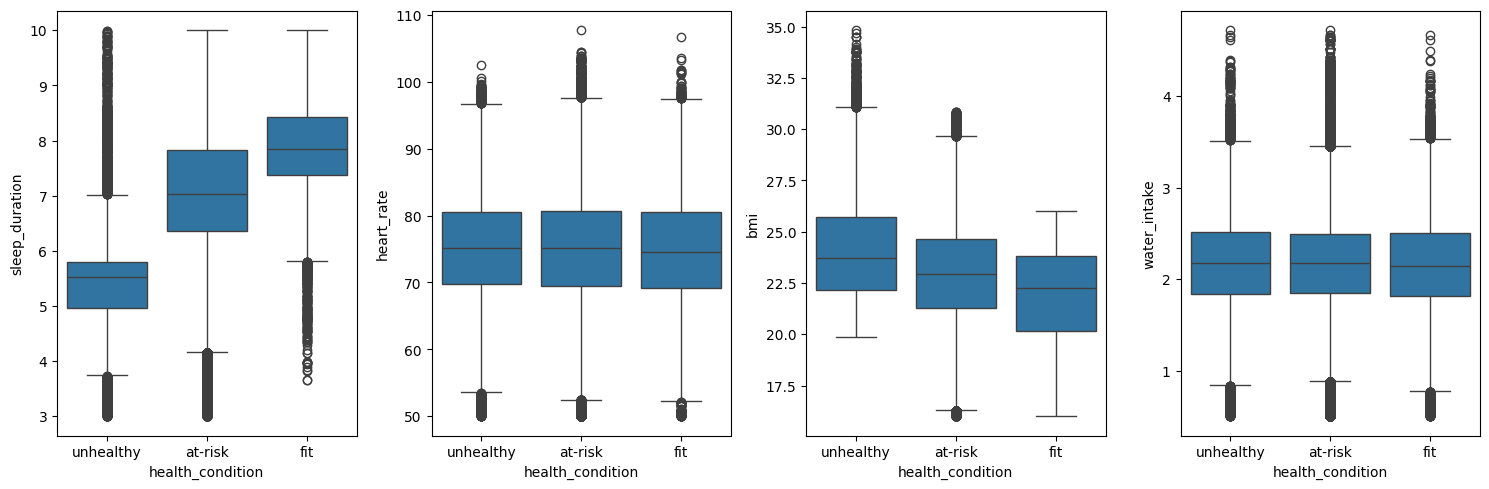

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

sns.boxplot(data=train, x="health_condition", y="sleep_duration", ax=axes[0])
sns.boxplot(data=train, x="health_condition", y="heart_rate", ax=axes[1])
sns.boxplot(data=train, x="health_condition", y="bmi", ax=axes[2])
sns.boxplot(data=train, x="health_condition", y="water_intake", ax=axes[3])

plt.tight_layout()
plt.show()

In [ ]:
# 1. sleep duration strong linear relationship with being fit or not, and there are outliers and they are possible so
# 2. Heart rate not much relationship with being fit or not
# 3. as expected unhealthy people cause they have more weight and less exercise they have more bmi and more bmi means less fit
# 4. not much relationship with water intake

# since our numerical columns are done let's move on to categorial columns and relationship between them and the target

In [ ]:
cat_cols = train.select_dtypes(include = "object").columns
print(cat_cols)

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')


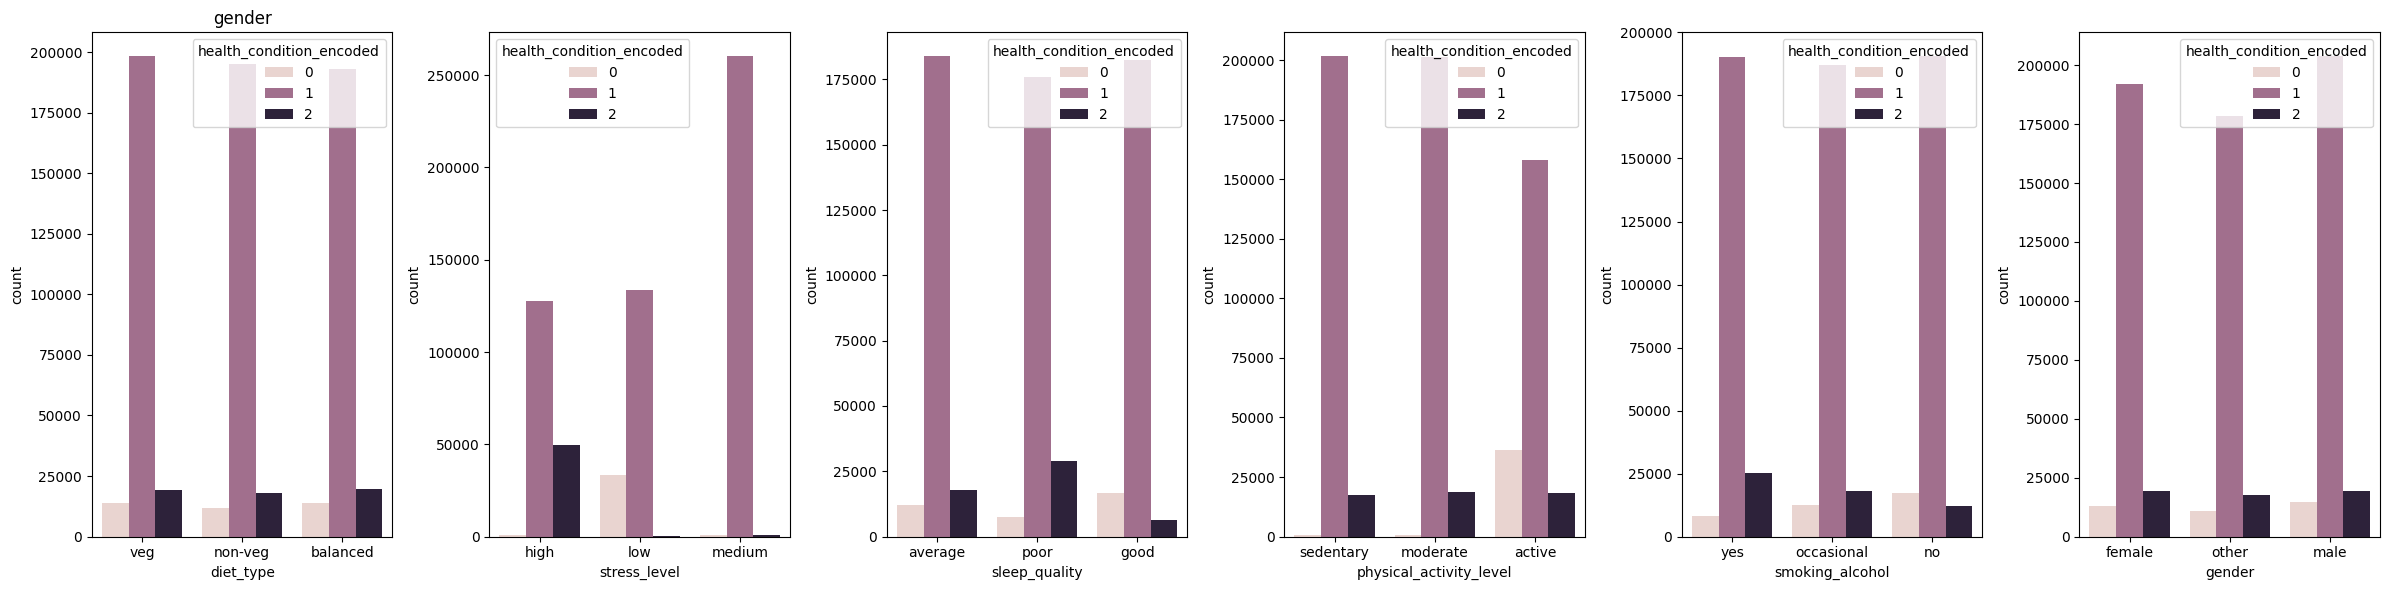

In [ ]:
fig,axes = plt.subplots(1,6, figsize = (24,6))
sns.countplot(data= train, x = "diet_type", hue = "health_condition_encoded", ax = axes[0])
axes[0].set_title("diet_type")
sns.countplot(data= train, x = "stress_level", hue = "health_condition_encoded", ax = axes[1])
axes[0].set_title("stress_level")
sns.countplot(data= train, x = "sleep_quality", hue = "health_condition_encoded", ax = axes[2])
axes[0].set_title("sleep_quality")
sns.countplot(data= train, x = "physical_activity_level", hue = "health_condition_encoded", ax = axes[3])
axes[0].set_title("physical_activity_level")
sns.countplot(data= train, x = "smoking_alcohol", hue = "health_condition_encoded", ax = axes[4])
axes[0].set_title("smoking_alcohol")
sns.countplot(data= train, x = "gender", hue = "health_condition_encoded", ax = axes[5])
axes[0].set_title("gender")
plt.tight_layout()
plt.show()

#hard to extract information later just use the value count in loop

In [ ]:
for col in cat_cols:
    print("\n", col)
    print(pd.crosstab(train[col],train["health_condition"]))

    #diet type very low predictive power, cause any diet can be healthy it mostly about macros
    #stress level has high predictive power, as low stress means more fit people, high stress mostly means they are unhealthy and medium has more risk
    #sleep quality is also same but to a lesser degree
    #active sleep quality highly relatives to being fit than being normal or sedative
    #smoking and alchol have relation to being not beig fit but to less degree
    #gender has no coorelation

    #in summary most catagorial data are very higly coorelated but gender and diet type have less affect overall


 health_condition
health_condition  at-risk    fit  unhealthy
health_condition                           
at-risk            592561      0          0
fit                     0  39803          0
unhealthy               0      0      57724

 diet_type
health_condition  at-risk    fit  unhealthy
diet_type                                  
balanced           193171  13884      19833
non-veg            195140  11600      18127
veg                198263  13968      19201

 stress_level
health_condition  at-risk    fit  unhealthy
stress_level                               
high               127592    624      49534
low                133608  33635        465
medium             260231    785        803

 sleep_quality
health_condition  at-risk    fit  unhealthy
sleep_quality                              
average            183850  12255      17843
good               182564  16810       6269
poor               176004   7344      28818

 physical_activity_level
health_condition         at-risk

In [ ]:
# # EDA
# 1. handling missing data

missing_for_num = train[num_cols].isnull().sum()
missing_for_cal = train[cat_cols].isnull().sum()
#now let's handle for numeric data now
# print(missing_for_num)
# print(train["sleep_duration"])  # since the sleep duration have very balanced data so filling with mean, median anything will be the same cause they are both same value
num_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]
for col in num_cols:
    train[col] = train[col].fillna(train[col].mean())
#all of them are very symmetric in nature and there are no visible outliers to consider

#now let's handle for catagorial data now
print(missing_for_cal)
train["diet_type"] = train["diet_type"].fillna(train["diet_type"].mode()[0])
#we can see a balance distribution and filling with any value won't do any harm
train["stress_level"] = train["stress_level"].fillna("Missing") # stress level being low median high matters and it can distort data if we do more
train["sleep_quality"] = train["sleep_quality"].fillna("Missing") # same things for below missing
train["physical_activity_level"] = train["physical_activity_level"].fillna("Missing")
train["smoking_alcohol"] = train["smoking_alcohol"].fillna("Missing")

train["gender"] = train["gender"].fillna(train["gender"].mode()[0])
#in the previous study of counting as well we said both gender there is not much relation so we can fill with any values

#seeing the data of the catagorial columns we can say that there is no column with incorrect datatyping so no need to check it

health_condition               0
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64


In [ ]:
# Feature engerring
# using eps to prevent division for 0
#1. ratio features
eps = 1e-6
train["calories_per_min"] = (train["calorie_expenditure"] /(train["exercise_duration"] + eps))
train["steps_per_min"] = (train["step_count"] /(train["exercise_duration"] + eps))
train["calories_per_step"] = (train["calorie_expenditure"] /(train["step_count"] + eps))
train["water_per_bmi"] = (train["water_intake"] /(train["bmi"] + eps))
train["exercise_per_bmi"] = (train["exercise_duration"] /(train["bmi"] + eps))
train["calories_per_bmi"] = (train["calorie_expenditure"] /(train["bmi"] + eps))
train["steps_per_sleep"] = (train["step_count"] /(train["sleep_duration"] + eps))
train["hydration_efficiency"] = (train["water_intake"] /(train["exercise_duration"] + eps))
train["hr_per_step"] = (train["heart_rate"] /(train["step_count"] + eps))
train["recovery_ratio"] = (train["sleep_duration"] /(train["exercise_duration"] + eps))

#2. intercation features
train["exercise_load"] = (train["heart_rate"] *train["exercise_duration"])
train["cardio_load"] = (train["heart_rate"] *train["bmi"])
train["recovery_score"] = (train["sleep_duration"] *train["exercise_duration"])

#3. groupby features
train["avg_hr_gender"] = (train.groupby("gender")["heart_rate"].transform("mean"))
train["avg_bmi_gender"] = (train.groupby("gender")["bmi"].transform("mean"))
train["hr_diff_gender"] = (train["heart_rate"] -train.groupby("gender")["heart_rate"].transform("mean"))
train["activity_count"] = (train.groupby("physical_activity_level")["id"].transform("count"))

In [ ]:
#encoding and pipelines
for col in cat_cols:
    print("=" * 50)
    print(col)
    print(train[col].value_counts(dropna=False))

health_condition
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64
diet_type
diet_type
veg         238333
balanced    226888
non-veg     224867
Name: count, dtype: int64
stress_level
stress_level
medium     261819
high       177750
low        167708
Missing     82811
Name: count, dtype: int64
sleep_quality
sleep_quality
average    213948
poor       212166
good       205643
Missing     58331
Name: count, dtype: int64
physical_activity_level
physical_activity_level
moderate     221041
sedentary    219784
active       212642
Missing       36621
Name: count, dtype: int64
smoking_alcohol
smoking_alcohol
yes           223730
no            219791
occasional    217985
Missing        28582
Name: count, dtype: int64
gender
gender
male      259129
female    224016
other     206943
Name: count, dtype: int64


In [ ]:
stress_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2,
    "Missing": 3
}

sleep_mapping = {
    "poor": 0,
    "average": 1,
    "good": 2,
    "Missing": 3
}

activity_mapping = {
    "sedentary": 0,
    "moderate": 1,
    "active": 2,
    "Missing": 3
}

smoking_mapping = {
    "no": 0,
    "occasional": 1,
    "yes": 2,
    "Missing": 3
}
train["stress_level"] =train["stress_level"].map(stress_mapping)
train["sleep_quality"] = train["sleep_quality"].map(sleep_mapping)
train["physical_activity_level"]= train["physical_activity_level"].map(activity_mapping)
train["smoking_alcohol"] = train["smoking_alcohol"].map(smoking_mapping)

ohe_cols = [
    "diet_type",
    "gender"
]

In [ ]:
train
drop_cols = [
    "health_condition",
    "id"
]
train = train.drop(columns = drop_cols, errors = "ignore")

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num",numeric_pipeline,num_cols),
    ("cat",categorical_pipeline,ohe_cols)
])


In [ ]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)
model_pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",model)
])

In [ ]:
X = train.drop(columns = ["health_condition_encoded"])
y = train["health_condition_encoded"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('e...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None, num_class=3, ...))])

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.871205205118173

In [ ]:
scores = cross_val_score(
    model_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores.mean())

0.8698948540887905


In [ ]:
param_dist = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.29),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 5)
}

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['sleep_duration',
                                                                                'heart_rate',
                                                                                'bmi',
                                                                                'calorie_expenditure',
                                                                                'step_count',
                                                                                'exercise_duration',
                                                                                'water_intake']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImpu...
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b73c25b7b30>,
                                        'model__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b73c25b4980>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b73d1705eb0>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b73de311430>},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print(random_search.best_score_)
best_model = random_search.best_estimator_

0.8709964316119333


In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8719514845889667
